# Random Forest Regression — Solution 4 to Problem 10.3

Random Forest regression for electric-load forecasting, continuing from the feature set engineered in Solution 3 (TFT). This is the best-performing of the four architectures.

Outputs: actuals-vs-predictions (Fig. 10.9), residual ACF (Fig. 10.10), Test MAPE / RMSE, and the feature-importance ranking.

*Reproduced result: Test MAPE = 0.0060, Test RMSE = 30.57 (book).*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from PythonTsa.plot_acf_pacf import acf_pacf_fig

## Feature engineering (from Solution 3)
Load the data, apply a log-transform to `load`, split into train/valid/test, then build calendar, cyclical, and lag features.

In [ ]:
tsdta = pd.read_csv('elec-temp.csv')
tsdta['time'] = pd.to_datetime(tsdta['time'])
tsdta.set_index('time', inplace=True)
tsdta['load'] = np.log(tsdta['load'])

valid_stdta = '2014-09-01 00:00:00'
test_stdta = '2014-11-01 00:00:00'
train_mask = tsdta.index < valid_stdta
valid_mask = (tsdta.index >= valid_stdta) & (tsdta.index < test_stdta)
test_mask = tsdta.index >= test_stdta
train_dat = tsdta.copy()[train_mask]
valid_dat = tsdta.copy()[valid_mask]
test_dat = tsdta.copy()[test_mask]

In [ ]:
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['days_in_year'] = df.index.map(lambda x: 366 if x.is_leap_year else 365)
    df['year_progress'] = (df['dayofyear'] - 1) / df['days_in_year']
    df['temp_angle'] = 2*np.pi*(df['temp']-df['temp'].min())/(df['temp'].max()-df['temp'].min())
    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
    df['week_sin'] = np.sin(2*np.pi*(df['dayofweek']*24 + df['hour'])/(7*24))
    df['week_cos'] = np.cos(2*np.pi*(df['dayofweek']*24 + df['hour'])/(7*24))
    df['year_sin'] = np.sin(2*np.pi*df['year_progress'])
    df['year_cos'] = np.cos(2*np.pi*df['year_progress'])
    df['daily_avg_temp'] = df.groupby(df.index.date)['temp'].transform('mean')
    df['temp_lag01'] = df['temp'].shift(1)
    df['temp_lag03'] = df['temp'].shift(3)
    df['temp_lag06'] = df['temp'].shift(6)
    df['temp_sin'] = np.sin(df['temp_angle'])
    df['temp_cos'] = np.cos(df['temp_angle'])
    df['rolling_24h_load'] = df['load'].rolling(window='24h', min_periods=1, closed='left').mean()
    df['load_lag01'] = df['load'].shift(1)
    df['load_lag02'] = df['load'].shift(2)
    df['load_lag03'] = df['load'].shift(3)
    df['load_lag06'] = df['load'].shift(6)
    df['load_lag12'] = df['load'].shift(12)
    df['load_lag23'] = df['load'].shift(23)
    df['load_lag24'] = df['load'].shift(24)
    df['load_diff'] = df['load'] - df['load_lag24']
    return df.drop(columns=['hour','dayofweek','dayofyear',
        'days_in_year','year_progress','temp_angle']).dropna()

train_dat = create_features(train_dat)
valid_dat = create_features(valid_dat)
test_dat = create_features(test_dat)

In [ ]:
def reg_data(train_dat, valid_dat=None, test_dat=None):
    temp_features = ['temp','daily_avg_temp','temp_lag01','temp_lag03','temp_lag06']
    qt = QuantileTransformer(output_distribution='normal')
    train_dat[temp_features] = qt.fit_transform(train_dat[temp_features])
    other_features = [c for c in train_dat.columns if c not in ['load']+temp_features]
    scaler = MinMaxScaler()
    train_dat[other_features] = scaler.fit_transform(train_dat[other_features])
    if valid_dat is not None:
        valid_dat[temp_features] = qt.transform(valid_dat[temp_features])
        valid_dat[other_features] = scaler.transform(valid_dat[other_features])
    if test_dat is not None:
        test_dat[temp_features] = qt.transform(test_dat[temp_features])
        test_dat[other_features] = scaler.transform(test_dat[other_features])
    return train_dat, valid_dat, test_dat

train_dat, valid_dat, test_dat = reg_data(train_dat, valid_dat, test_dat)
test_dates = test_dat.index[:168]
actual_load = np.exp(test_dat['load'].values[:168])
actual_load = pd.Series(data=actual_load, index=test_dates, name='Actual load')

## Random Forest model (Solution 4)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfmod = RandomForestRegressor(n_estimators=100, max_depth=None)
X = train_dat.drop(columns=['load'])
y = train_dat['load']
rfmodfit = rfmod.fit(X, y)
X_test = test_dat.drop(columns=['load'])
Y_pred = rfmod.predict(X_test)
Y_pred = np.exp(Y_pred)
rfpred_load = pd.Series(data=Y_pred[:168], index=test_dates, name='RF_pred_load')
mape = mean_absolute_percentage_error(actual_load, rfpred_load)
rmse = np.sqrt(mean_squared_error(actual_load, rfpred_load))
print(f'Test MAPE: {mape:.8f}, Test RMSE: {rmse:.4f}')

Test MAPE: 0.00604216, Test RMSE: 30.5709


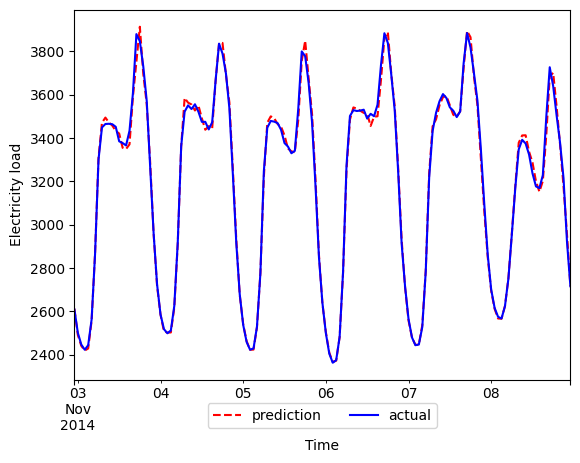

In [ ]:
dfp = pd.DataFrame({'prediction': rfpred_load, 'actual': actual_load})
dfp[23:168].plot(style=['--r', '-b'])
plt.xlabel('Time')
plt.ylabel('Electricity load')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.savefig('rf_actual_vs_pred.png', transparent=True, bbox_inches='tight')
plt.show()

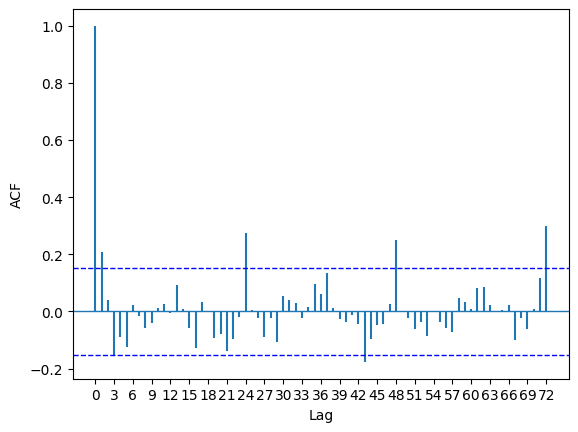

In [ ]:
resid = actual_load - rfpred_load
acf_pacf_fig(resid, lag=72)
plt.savefig('rf_residual_acf_pacf.png', transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
pd.Series(rfmod.feature_importances_, index=X.columns).sort_values(ascending=False)

load_lag01          0.826657
load_lag24          0.098061
hour_cos            0.031818
load_diff           0.023644
load_lag23          0.006848
load_lag12          0.003490
hour_sin            0.002555
load_lag02          0.001729
load_lag06          0.001195
rolling_24h_load    0.000608
load_lag03          0.000605
year_cos            0.000535
temp_cos            0.000323
week_sin            0.000307
daily_avg_temp      0.000290
temp_lag06          0.000262
year_sin            0.000229
temp_lag03          0.000214
week_cos            0.000182
temp_lag01          0.000151
temp                0.000149
temp_sin            0.000149
dtype: float64
